In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

In [ ]:
df = pd.read_excel("100_Pre_done_Combined.xlsx")
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
df.head()

(21349, 17)
['Material', 'SLoc', 'Quantity', 'Pstng Date', 'order', 'Equipment', 'Technician name', 'Year', 'Tavg', 'Tmax', 'Tmin', 'RH', 'Month', 'Season', 'Delta_T', 'Region', 'Location']
Material             int64
SLoc                object
Quantity             int64
Pstng Date             str
order                int64
Equipment              str
Technician name        str
Year                 int64
Tavg               float64
Tmax               float64
Tmin               float64
RH                 float64
Month                int64
Season                 str
Delta_T            float64
Region                 str
Location               str
dtype: object


,Material,SLoc,Quantity,Pstng Date,order,Equipment,Technician name,Year,Tavg,Tmax,Tmin,RH,Month,Season,Delta_T,Region,Location
0,594479,5023,-1,2020-01-04,48550533,10930429,Anil Sharma,2020,12.94,21.27,7.26,58.52,1,Winter,14.01,North1,Haryana
1,594479,5024,-1,2020-01-06,48556766,10844557,Jogendra Singh,2020,14.94,22.58,9.03,56.47,1,Winter,13.55,North1,Jaipur
2,594479,5030,-1,2020-01-06,48550093,10517828,Himanshu Kushwaha,2020,13.70,21.92,8.25,55.23,1,Winter,13.67,North1,Delhi
3,594479,5002,-1,2020-01-06,48550185,10519283,Prasad Chokhat,2020,22.83,30.49,16.34,68.83,1,Winter,14.15,West1,Navi Mumbai
4,594479,5044,-1,2020-01-06,48554032,10836205,Joby Varghese,2020,28.71,32.68,25.08,68.80,1,Winter,7.60,South,Cochin


In [3]:
# Fix region naming inconsistency
df['Region'] = df['Region'].str.strip().replace({'West 1': 'West1'})

# Create absolute failure quantity
df['Abs_Quantity'] = df['Quantity'].abs()

# Verify
print(df['Region'].unique())
print(df['Abs_Quantity'].describe())

<StringArray>
['North1', 'West1', 'South', 'West2', 'East', 'North2']
Length: 6, dtype: str
count    21349.000000
mean         1.004356
std          0.112168
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: Abs_Quantity, dtype: float64


In [4]:
monthly = df.groupby(['Year', 'Month', 'Region', 'Season']).agg(
    Failure_Count = ('Abs_Quantity', 'sum'),
    Avg_Tmax      = ('Tmax', 'mean'),
    Avg_Tavg      = ('Tavg', 'mean'),
    Avg_RH        = ('RH', 'mean'),
    Avg_DeltaT    = ('Delta_T', 'mean')
).reset_index()
print(monthly.shape)
monthly.head(10)

(434, 9)


,Year,Month,Region,Season,Failure_Count,Avg_Tmax,Avg_Tavg,Avg_RH,Avg_DeltaT
0,2020,1,East,Winter,1,21.690000,16.990000,87.300000,8.970000
1,2020,1,North1,Winter,41,20.193902,12.695122,66.758780,13.396585
2,2020,1,South,Winter,11,30.833636,23.628182,62.977273,13.050000
3,2020,1,West1,Winter,25,28.909200,21.991600,67.276000,12.318000
4,2020,1,West2,Winter,4,27.602500,20.165000,64.217500,13.772500
5,2020,2,North1,Winter,48,25.652917,16.504792,52.396250,16.529167
6,2020,2,North2,Winter,1,9.010000,4.060000,65.580000,9.710000
7,2020,2,South,Winter,5,31.790000,24.854000,63.144000,12.366000
8,2020,2,West1,Winter,29,34.123103,25.694828,48.503793,14.818276
9,2020,2,West2,Winter,3,34.036667,25.066667,31.973333,16.723333


In [5]:
sloc_count = df.groupby(['Year', 'Month', 'Region'])['SLoc'].nunique().reset_index()
sloc_count.columns = ['Year', 'Month', 'Region', 'Active_SLocs']

monthly = monthly.merge(sloc_count, on=['Year', 'Month', 'Region'])
monthly['Failure_Rate'] = monthly['Failure_Count'] / monthly['Active_SLocs']

               Failure_Count  Avg_Tmax  Avg_Tavg    Avg_RH  Avg_DeltaT
Failure_Count       1.000000  0.043924 -0.021898 -0.255043    0.168465
Avg_Tmax            0.043924  1.000000  0.910495 -0.512629    0.263085
Avg_Tavg           -0.021898  0.910495  1.000000 -0.151579   -0.156400
Avg_RH             -0.255043 -0.512629 -0.151579  1.000000   -0.888464
Avg_DeltaT          0.168465  0.263085 -0.156400 -0.888464    1.000000


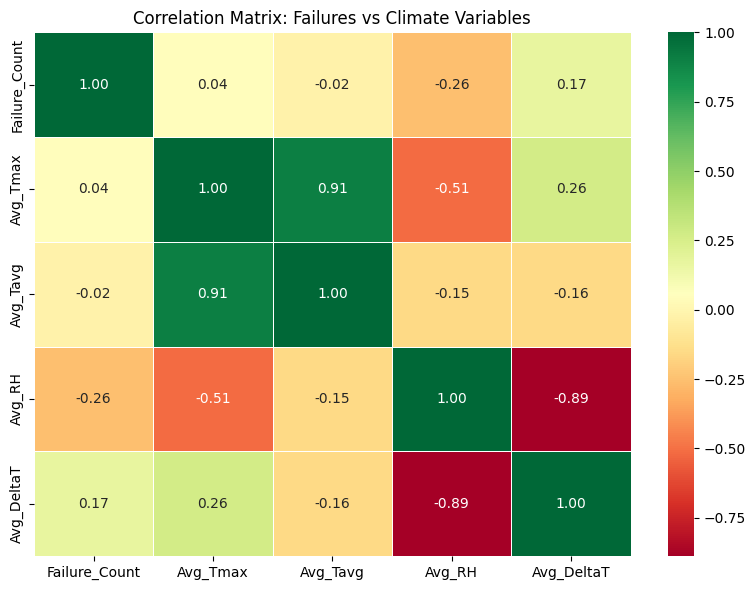

In [6]:
corr_cols = ['Failure_Count', 'Avg_Tmax', 'Avg_Tavg', 'Avg_RH', 'Avg_DeltaT']
corr_matrix = monthly[corr_cols].corr()

print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix: Failures vs Climate Variables")
plt.tight_layout()
plt.savefig("01_correlation_heatmap.png", dpi=150)
plt.show()

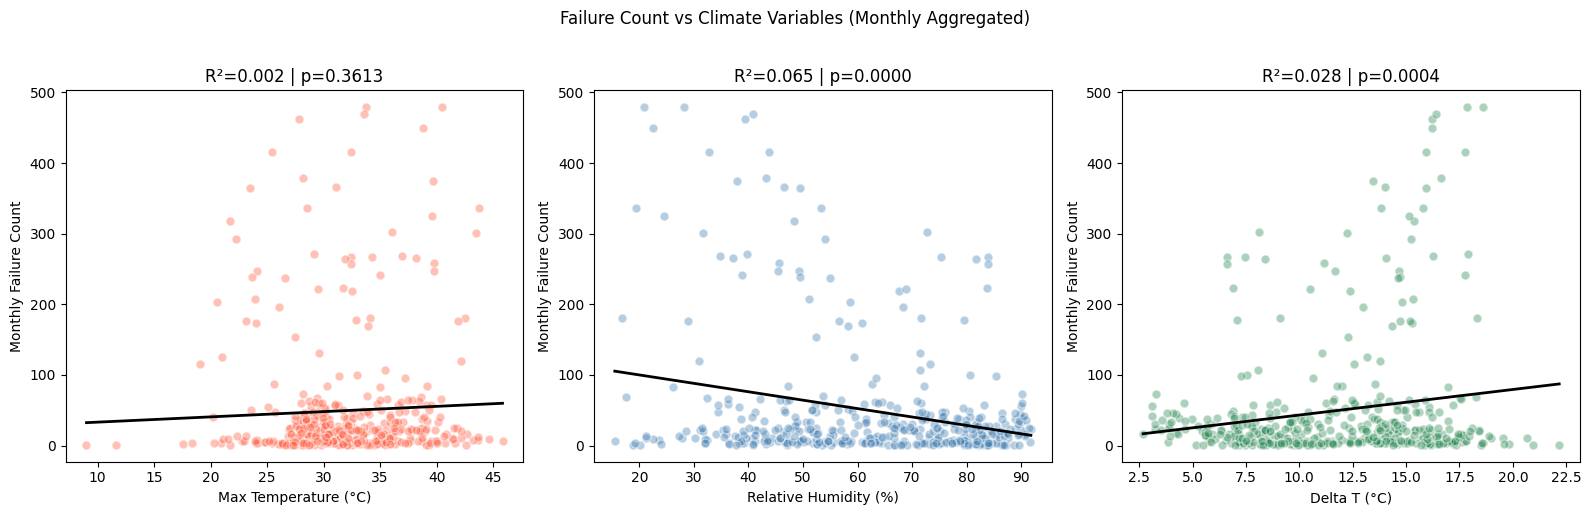

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = ['Avg_Tmax', 'Avg_RH', 'Avg_DeltaT']
labels    = ['Max Temperature (°C)', 'Relative Humidity (%)', 'Delta T (°C)']
colors    = ['tomato', 'steelblue', 'seagreen']

for ax, var, label, color in zip(axes, variables, labels, colors):
    x = monthly[var]
    y = monthly['Failure_Count']
    slope, intercept, r, p, _ = stats.linregress(x, y)
    ax.scatter(x, y, alpha=0.4, color=color, edgecolors='white', s=40)
    ax.plot(sorted(x), [slope * xi + intercept for xi in sorted(x)],
            color='black', linewidth=2)
    ax.set_xlabel(label)
    ax.set_ylabel('Monthly Failure Count')
    ax.set_title(f'R²={r**2:.3f} | p={p:.4f}')

plt.suptitle("Failure Count vs Climate Variables (Monthly Aggregated)", y=1.02)
plt.tight_layout()
plt.savefig("02_scatter_regression.png", dpi=150)
plt.show()

C:\Users\Amey\AppData\Local\Temp\ipykernel_27176\1592832684.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly, x='Season', y='Failure_Count',


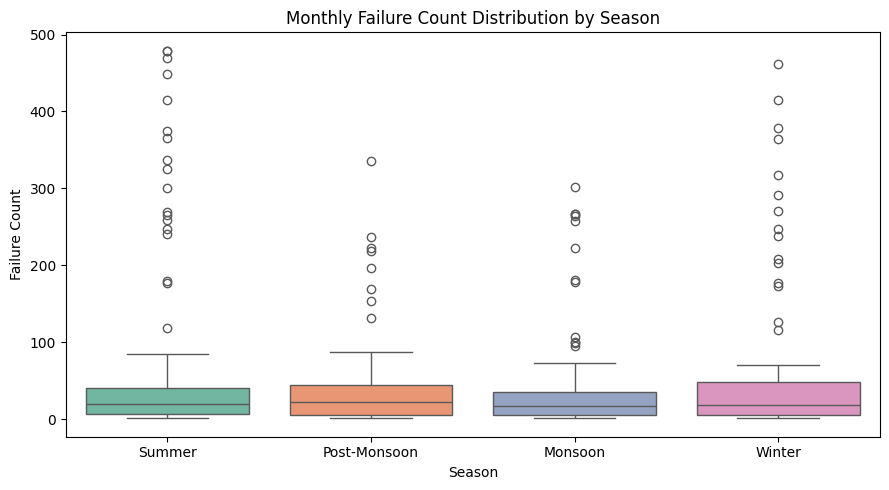

In [8]:
plt.figure(figsize=(9, 5))
season_order = ['Summer', 'Post-Monsoon', 'Monsoon', 'Winter']

sns.boxplot(data=monthly, x='Season', y='Failure_Count',
            order=season_order, palette='Set2')

plt.title("Monthly Failure Count Distribution by Season")
plt.ylabel("Failure Count")
plt.tight_layout()
plt.savefig("03_season_boxplot.png", dpi=150)
plt.show()

In [9]:
groups = [
    monthly[monthly['Season'] == s]['Failure_Count'].values
    for s in ['Summer', 'Winter', 'Monsoon', 'Post-Monsoon']
]

f_stat, p_val = f_oneway(*groups)

print(f"ANOVA Result")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_val:.6f}")

if p_val < 0.05:
    print("  ✅ Seasonal differences are STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("  ❌ No significant difference across seasons")

ANOVA Result
  F-statistic : 1.0832
  p-value     : 0.355920
  ❌ No significant difference across seasons


  Tmax_Band  Total_Failures  Avg_Failures  Months_Count
0       <25            2657     83.031250            32
1     25-30            5367     41.604651           129
2     30-35            6808     43.363057           157
3     35-40            4668     53.045455            88
4       40+            1942     69.357143            28


C:\Users\Amey\AppData\Local\Temp\ipykernel_27176\4194844538.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=band_summary, x='Tmax_Band', y='Avg_Failures', palette='YlOrRd')


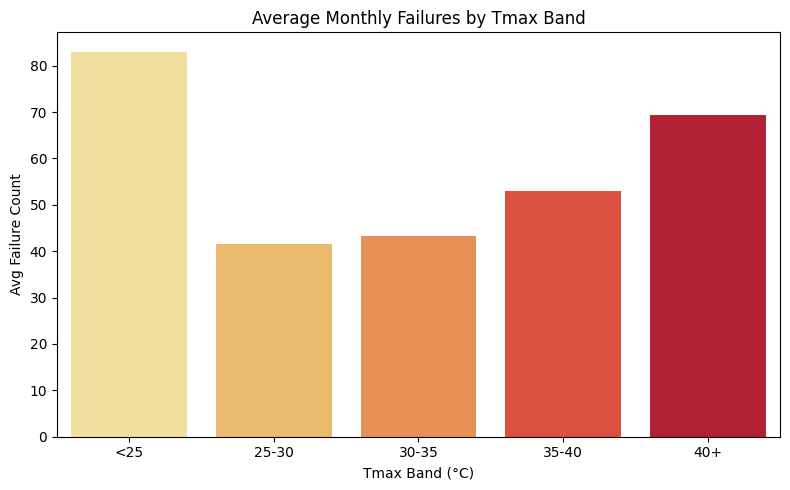

In [10]:
bins   = [0, 25, 30, 35, 40, 60]
labels = ['<25', '25-30', '30-35', '35-40', '40+']

monthly['Tmax_Band'] = pd.cut(monthly['Avg_Tmax'], bins=bins, labels=labels)

band_summary = monthly.groupby('Tmax_Band', observed=True).agg(
    Total_Failures = ('Failure_Count', 'sum'),
    Avg_Failures   = ('Failure_Count', 'mean'),
    Months_Count   = ('Failure_Count', 'count')
).reset_index()

print(band_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=band_summary, x='Tmax_Band', y='Avg_Failures', palette='YlOrRd')
plt.title("Average Monthly Failures by Tmax Band")
plt.xlabel("Tmax Band (°C)")
plt.ylabel("Avg Failure Count")
plt.tight_layout()
plt.savefig("04_tmax_band.png", dpi=150)
plt.show()

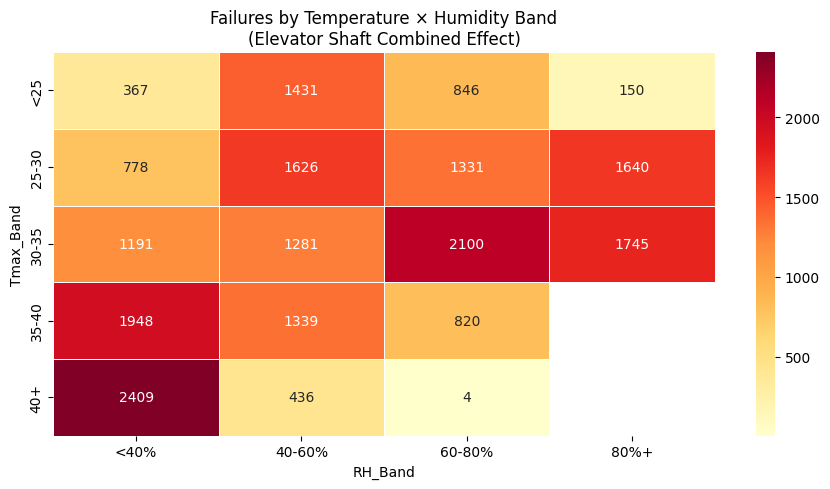

In [11]:
df['Tmax_Band'] = pd.cut(df['Tmax'], bins=[0,25,30,35,40,60],
                          labels=['<25','25-30','30-35','35-40','40+'])
df['RH_Band']   = pd.cut(df['RH'],   bins=[0,40,60,80,100],
                          labels=['<40%','40-60%','60-80%','80%+'])

combo = df.groupby(['Tmax_Band', 'RH_Band'], observed=True).agg(
    Total_Failures = ('Abs_Quantity', 'sum')
).reset_index()

pivot = combo.pivot(index='Tmax_Band', columns='RH_Band', values='Total_Failures')

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title("Failures by Temperature × Humidity Band\n(Elevator Shaft Combined Effect)")
plt.tight_layout()
plt.savefig("05_temp_humidity_heatmap.png", dpi=150)
plt.show()

   Region  Total_Failures  Avg_Monthly_Failures
1  North1            6144            236.307692
4   West1            1031             39.653846
3   South             558             21.461538
5   West2             388             16.166667
2  North2             191              8.304348
0    East              84              3.818182


C:\Users\Amey\AppData\Local\Temp\ipykernel_27176\1634970394.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_summary, x='Region', y='Total_Failures', palette='magma')


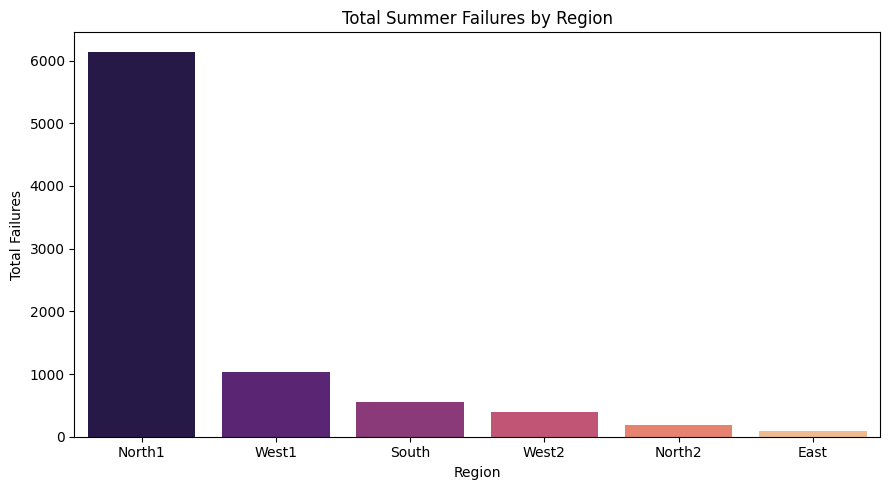

In [12]:
summer = monthly[monthly['Season'] == 'Summer']

region_summary = summer.groupby('Region')['Failure_Count'].agg(['sum','mean']).reset_index()
region_summary.columns = ['Region', 'Total_Failures', 'Avg_Monthly_Failures']
region_summary = region_summary.sort_values('Total_Failures', ascending=False)

print(region_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=region_summary, x='Region', y='Total_Failures', palette='magma')
plt.title("Total Summer Failures by Region")
plt.ylabel("Total Failures")
plt.tight_layout()
plt.savefig("06_region_summer_failures.png", dpi=150)
plt.show()

In [13]:
print("=" * 55)
print("       PHASE 1 — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"\n1. CORRELATION (strongest driver):")
print(f"   Tmax     vs Failures : {monthly[['Avg_Tmax','Failure_Count']].corr().iloc[0,1]:.3f}")
print(f"   RH       vs Failures : {monthly[['Avg_RH','Failure_Count']].corr().iloc[0,1]:.3f}")
print(f"   Delta_T  vs Failures : {monthly[['Avg_DeltaT','Failure_Count']].corr().iloc[0,1]:.3f}")

print(f"\n2. ANOVA p-value        : {p_val:.6f}  {'✅ Significant' if p_val < 0.05 else '❌ Not significant'}")

print(f"\n3. HIGHEST RISK Tmax Band:")
print(f"   {band_summary.loc[band_summary['Avg_Failures'].idxmax(), 'Tmax_Band']} °C band")

print(f"\n4. HIGHEST RISK Region (Summer):")
print(f"   {region_summary.iloc[0]['Region']} with {region_summary.iloc[0]['Total_Failures']:.0f} total failures")
print("=" * 55)

       PHASE 1 — KEY FINDINGS SUMMARY

1. CORRELATION (strongest driver):
   Tmax     vs Failures : 0.044
   RH       vs Failures : -0.255
   Delta_T  vs Failures : 0.168

2. ANOVA p-value        : 0.355920  ❌ Not significant

3. HIGHEST RISK Tmax Band:
   <25 °C band

4. HIGHEST RISK Region (Summer):
   North1 with 6144 total failures


In [40]:
yearly = monthly.groupby('Year').agg(
    Total_Failures = ('Failure_Count', 'sum'),
    Avg_Rate       = ('Failure_Rate', 'mean')
).reset_index()
print(yearly)

   Year  Total_Failures   Avg_Rate
0  2020             967   4.543678
1  2021            1682   6.005072
2  2022            2786   7.961469
3  2023            3840   9.784675
4  2024            5126  12.352040
5  2025            5177  14.517772
6  2026            1960  16.808230


In [14]:
plt.figure(figsize=(9, 5))
plt.plot(yearly['Year'], yearly['Avg_Rate'], marker='o', 
         color='tomato', linewidth=2.5, markersize=8)
plt.fill_between(yearly['Year'], yearly['Avg_Rate'], alpha=0.1, color='tomato')
plt.title("Failure Rate per Active SLoc — Year over Year")
plt.xlabel("Year")
plt.ylabel("Avg Failures per SLoc per Month")
plt.xticks(yearly['Year'])
plt.tight_layout()
plt.savefig("07_yoy_failure_rate.png", dpi=150)
plt.show()

NameError: name 'yearly' is not defined

<Figure size 900x500 with 0 Axes>